# CFPB Credit Card Complaint Dashboard
**Portfolio project** — Business Analyst, Credit Card Program
Data: [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/)
Analyst: Cheuk Hin Yu · Built: 2026-09-17

---

### What this notebook does
1. Downloads the full CFPB complaint database and filters to credit card complaints
2. Runs exploratory data analysis (EDA) to understand the dataset
3. Builds 4 business analyses:
   - Monthly complaint volume by issue category
   - Top issuers by volume + timely response rate
   - State-level complaint rate per 100k population
   - Resolution quality breakdown by issuer
4. Synthesises findings into an executive summary with a recommended action


## 0. Setup & Imports

In [9]:
import os, io, zipfile, warnings
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px

warnings.filterwarnings("ignore")

# ── Paths (relative to this notebook's location) ──────────────────────────────
ROOT     = Path("..").resolve()
DATA_DIR = ROOT / "data"
OUT_DIR  = ROOT / "outputs"
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# ── Chart defaults ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.figsize": (13, 6), "figure.dpi": 120})

print(f"Data dir  : {DATA_DIR}")
print(f"Output dir: {OUT_DIR}")


Data dir  : /Users/yucheukhin/Documents/260917_cfpb_complaints/data
Output dir: /Users/yucheukhin/Documents/260917_cfpb_complaints/outputs


## 1. Data Download & Load

The CFPB publishes a bulk CSV (~300 MB compressed) updated daily.
We download it once, save it locally, then filter to **credit card** rows only.
Chunked reading keeps memory usage low on the full ~3 GB uncompressed file.


In [10]:
ZIP_URL  = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"
CSV_PATH = DATA_DIR / "complaints.csv"

if not CSV_PATH.exists():
    print("Downloading CFPB complaints ZIP (~300 MB) — this runs once...")
    resp  = requests.get(ZIP_URL, stream=True)
    total = int(resp.headers.get("content-length", 0))
    buf, downloaded = [], 0
    for chunk in resp.iter_content(chunk_size=2 * 1024 * 1024):
        buf.append(chunk)
        downloaded += len(chunk)
        pct = downloaded / total * 100 if total else 0
        print(f"\r  {pct:.0f}%  ({downloaded / 1e6:.0f} MB / {total / 1e6:.0f} MB)", end="")
    print("\nExtracting...")
    zipfile.ZipFile(io.BytesIO(b"".join(buf))).extractall(DATA_DIR)
    print(f"Saved → {CSV_PATH}")
else:
    print(f"Using cached file: {CSV_PATH}")

# ── Filter to credit card on the fly (chunked for memory efficiency) ──────────
print("Loading credit card complaints...")
chunks = []
for chunk in pd.read_csv(CSV_PATH, chunksize=100_000, low_memory=False):
    mask = chunk["Product"].str.contains("credit card", case=False, na=False)
    chunks.append(chunk[mask])

df = pd.concat(chunks, ignore_index=True)
print(f"\n✓ {len(df):,} credit card complaints loaded ({df.shape[1]} columns)")


Using cached file: /Users/yucheukhin/Documents/260917_cfpb_complaints/data/complaints.csv
Loading credit card complaints...

✓ 549,582 credit card complaints loaded (15 columns)


## 2. Exploratory Data Analysis (EDA)

Before building any chart, we need to understand:
- **Date range** — how far back does the data go?
- **Nulls** — which fields are sparsely populated?
- **Top categories** — what issues and companies dominate?

This shapes every analysis that follows.


In [11]:
# ── Parse date (do this once; used by all analyses) ───────────────────────────
df["Date received"] = pd.to_datetime(df["Date received"])
df["Month"]         = df["Date received"].dt.to_period("M").dt.to_timestamp()

print(f"Date range: {df['Date received'].min().date()}  →  {df['Date received'].max().date()}")
print(f"Shape     : {df.shape}\n")

print("Null rate (%) — top 10 sparse columns:")
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False).head(10).to_string())

print("\nTop 8 issues:")
print(df["Issue"].value_counts().head(8).to_string())

print("\nTop 8 companies by complaint volume:")
print(df["Company"].value_counts().head(8).to_string())

print("\nTimely response? distribution:")
print(df["Timely response?"].value_counts().to_string())

print("\nCompany response categories:")
print(df["Company response to consumer"].value_counts().head(8).to_string())


Date range: 2011-12-01  →  2026-09-15
Shape     : (549582, 16)

Null rate (%) — top 10 sparse columns:
Tags                       84.0
Company public response    56.9
Sub-issue                  16.8
Sub-product                16.2
State                       1.2
Date received               0.0
Product                     0.0
Issue                       0.0
Company                     0.0
ZIP code                    0.0

Top 8 issues:
Issue
Problem with a purchase shown on your statement                    112296
Getting a credit card                                               54518
Other features, terms, or problems                                  48030
Fees or interest                                                    43187
Incorrect information on your report                                39916
Problem when making payments                                        31131
Closing your account                                                30030
Problem with a company's investigation

## 3. Analysis 1 — Monthly Complaint Volume by Issue Category

**Business question:** Which complaint types are growing? Are any issues spiking recently?
**Why it matters:** A card program manager tracks this to anticipate servicing load and
flag issues before they attract regulatory attention.

We plot the top 5 issue categories as monthly time series.


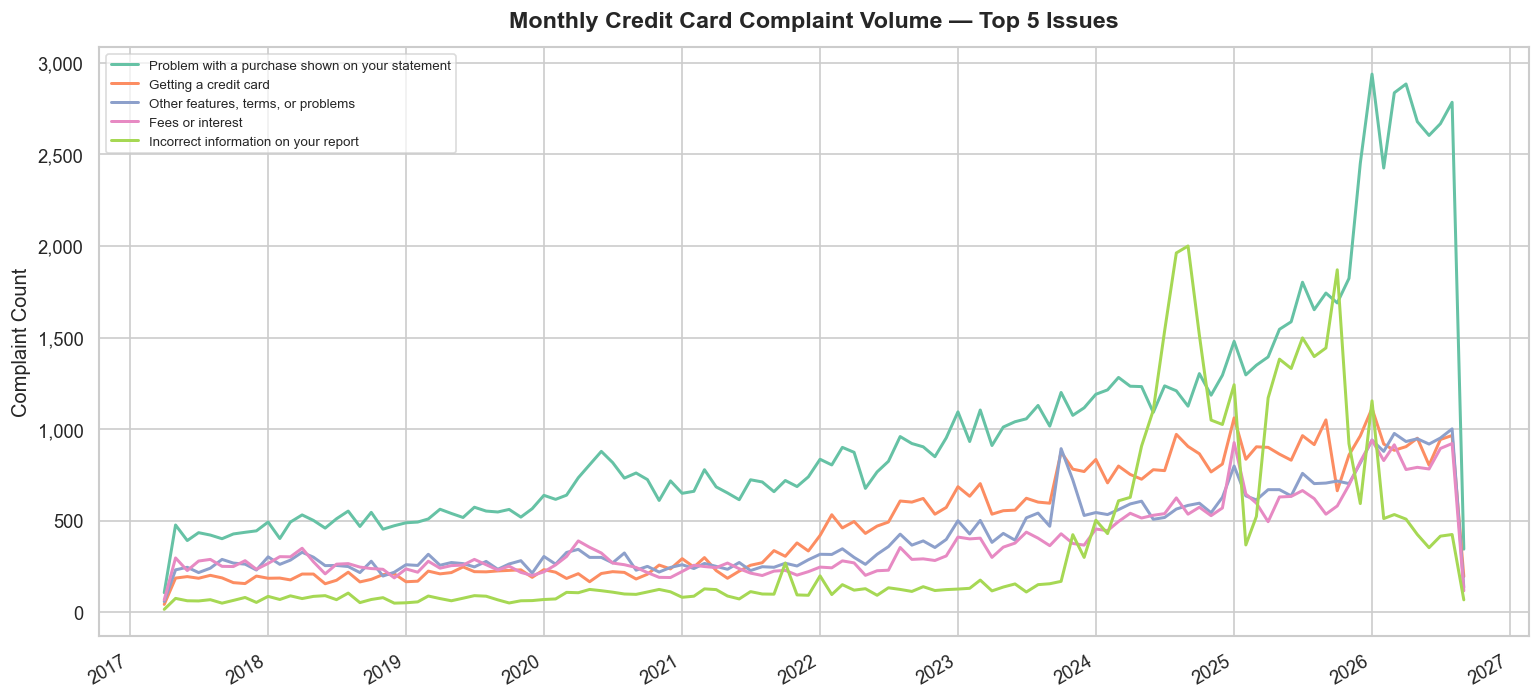

Saved → outputs/01_monthly_volume_by_issue.png


In [12]:
top_issues = df["Issue"].value_counts().head(5).index.tolist()
df_top     = df[df["Issue"].isin(top_issues)]

monthly_issues = (
    df_top.groupby(["Month", "Issue"])
    .size()
    .reset_index(name="Count")
)

fig, ax = plt.subplots()
for issue in top_issues:
    subset = monthly_issues[monthly_issues["Issue"] == issue]
    ax.plot(subset["Month"], subset["Count"], label=issue, linewidth=1.8)

ax.set_title("Monthly Credit Card Complaint Volume — Top 5 Issues",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("Complaint Count")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper left", fontsize=8, framealpha=0.7)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "01_monthly_volume_by_issue.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/01_monthly_volume_by_issue.png")


## 4. Analysis 2 — Top Issuers: Volume vs. Timely Response Rate

**Business question:** Which banks generate the most complaints, and are they responding on time?
**Why it matters:** The CFPB tracks timely response as a compliance indicator.
Issuers below 90% face heightened scrutiny.

Left panel = complaint volume. Right panel = timely response rate.
Red bars = below 90% threshold.


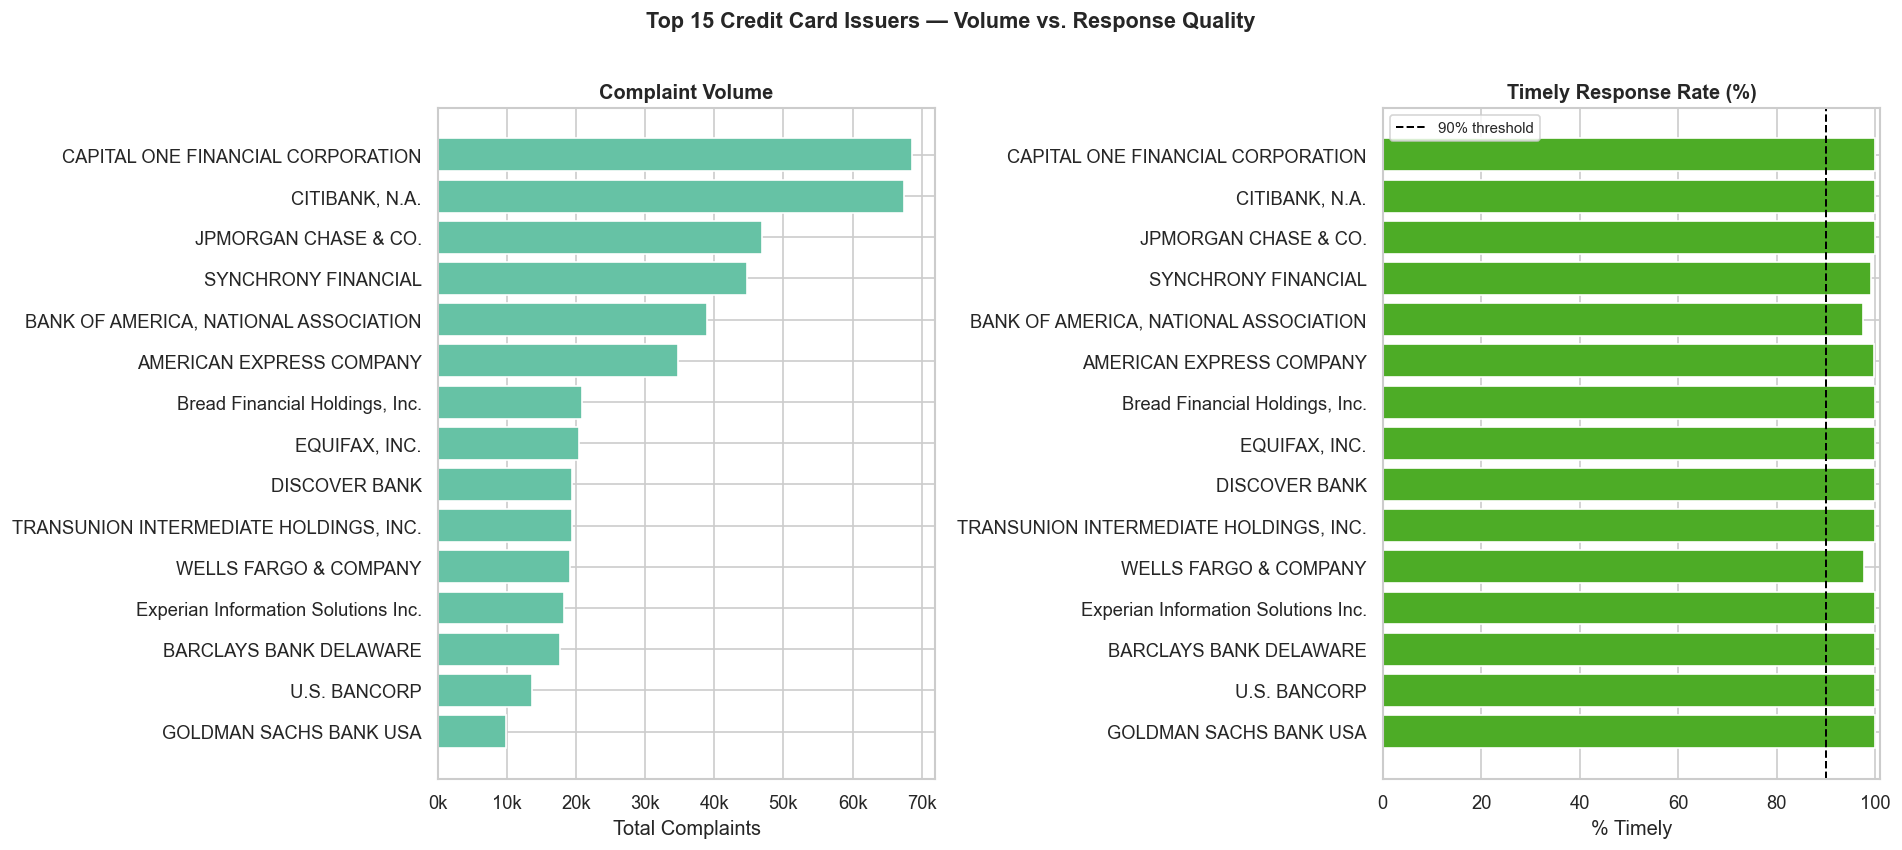

Saved → outputs/02_issuers_volume_response.png


In [13]:
TOP_N = 15

vol = df["Company"].value_counts().head(TOP_N).reset_index()
vol.columns = ["Company", "Complaints"]

timely_rate = (
    df[df["Company"].isin(vol["Company"])]
    .groupby("Company")["Timely response?"]
    .apply(lambda x: (x.str.lower() == "yes").mean() * 100)
    .reset_index(name="Timely_Pct")
)

merged = vol.merge(timely_rate, on="Company").sort_values("Complaints", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left — volume
ax1.barh(merged["Company"], merged["Complaints"],
         color=sns.color_palette("Set2")[0])
ax1.set_title("Complaint Volume", fontweight="bold")
ax1.set_xlabel("Total Complaints")
ax1.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# Right — timely response rate
bar_colors = ["#d73027" if v < 90 else "#4dac26" for v in merged["Timely_Pct"]]
ax2.barh(merged["Company"], merged["Timely_Pct"], color=bar_colors)
ax2.axvline(90, color="black", linestyle="--", linewidth=1.2, label="90% threshold")
ax2.set_title("Timely Response Rate (%)", fontweight="bold")
ax2.set_xlabel("% Timely")
ax2.set_xlim(0, 101)
ax2.legend(fontsize=9)

plt.suptitle(f"Top {TOP_N} Credit Card Issuers — Volume vs. Response Quality",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "02_issuers_volume_response.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/02_issuers_volume_response.png")


## 5. Analysis 3 — State Heatmap: Complaints per 100k Population

**Business question:** Which states are disproportionately complaint-heavy relative to their population?
**Why it matters:** High per-capita rates can signal weak servicing in that market,
a concentrated card portfolio, or an emerging consumer protection issue.

We normalise by 2020 US Census state populations. Saved as an interactive HTML map.


In [14]:
# 2020 US Census state populations
STATE_POP = {
    "AL": 5024279,  "AK": 733391,   "AZ": 7151502,  "AR": 3011524,  "CA": 39538223,
    "CO": 5773714,  "CT": 3605944,  "DE": 989948,   "FL": 21538187, "GA": 10711908,
    "HI": 1455271,  "ID": 1839106,  "IL": 12812508, "IN": 6785528,  "IA": 3190369,
    "KS": 2937880,  "KY": 4505836,  "LA": 4657757,  "ME": 1362359,  "MD": 6177224,
    "MA": 7029917,  "MI": 10077331, "MN": 5706494,  "MS": 2961279,  "MO": 6154913,
    "MT": 1084225,  "NE": 1961504,  "NV": 3104614,  "NH": 1377529,  "NJ": 9288994,
    "NM": 2117522,  "NY": 20201249, "NC": 10439388, "ND": 779094,   "OH": 11799448,
    "OK": 3959353,  "OR": 4237256,  "PA": 13002700, "RI": 1097379,  "SC": 5118425,
    "SD": 886667,   "TN": 6910840,  "TX": 29145505, "UT": 3271616,  "VT": 643077,
    "VA": 8631393,  "WA": 7705281,  "WV": 1793716,  "WI": 5893718,  "WY": 576851,
    "DC": 689545,
}

state_df = (
    df["State"].value_counts()
    .reset_index()
    .rename(columns={"State": "State", "count": "Complaints"})
)
state_df.columns = ["State", "Complaints"]
state_df["Population"] = state_df["State"].map(STATE_POP)
state_df = state_df.dropna(subset=["Population"])
state_df["Per_100k"] = (state_df["Complaints"] / state_df["Population"] * 100_000).round(1)

fig_map = px.choropleth(
    state_df,
    locations="State",
    locationmode="USA-states",
    color="Per_100k",
    scope="usa",
    color_continuous_scale="Oranges",
    title="Credit Card Complaints per 100k Population by State",
    labels={"Per_100k": "per 100k pop."},
    hover_data={"Complaints": ":,", "Per_100k": ":.1f"},
)
fig_map.update_layout(
    title_font_size=14,
    geo=dict(showlakes=True, lakecolor="lightblue"),
    coloraxis_colorbar=dict(title="per 100k"),
)
html_path = OUT_DIR / "03_state_heatmap.html"
fig_map.write_html(str(html_path))
fig_map.show()

print(f"Saved → outputs/03_state_heatmap.html  (open in browser for interactive view)")
print("\nTop 10 states by complaints per 100k:")
print(state_df.nlargest(10, "Per_100k")[["State", "Complaints", "Per_100k"]].to_string(index=False))


Saved → outputs/03_state_heatmap.html  (open in browser for interactive view)

Top 10 states by complaints per 100k:
State  Complaints  Per_100k
   DC        2931     425.1
   DE        3042     307.3
   FL       50746     235.6
   NV        7188     231.5
   NJ       21095     227.1
   NY       44922     222.4
   MD       13336     215.9
   GA       21693     202.5
   VA       16890     195.7
   CA       76372     193.2


## 6. Analysis 4 — Resolution Quality by Issuer

**Business question:** When a complaint is closed, how is it resolved?
**Why it matters:** "Closed with monetary relief" means the company conceded something.
"Closed with explanation" means they explained their position without paying out.
A high explanation-only rate can signal a company that fights complaints rather than
resolving them — a pattern CFPB supervisors flag.

We show the resolution breakdown as a stacked 100% bar chart for the top 10 issuers.


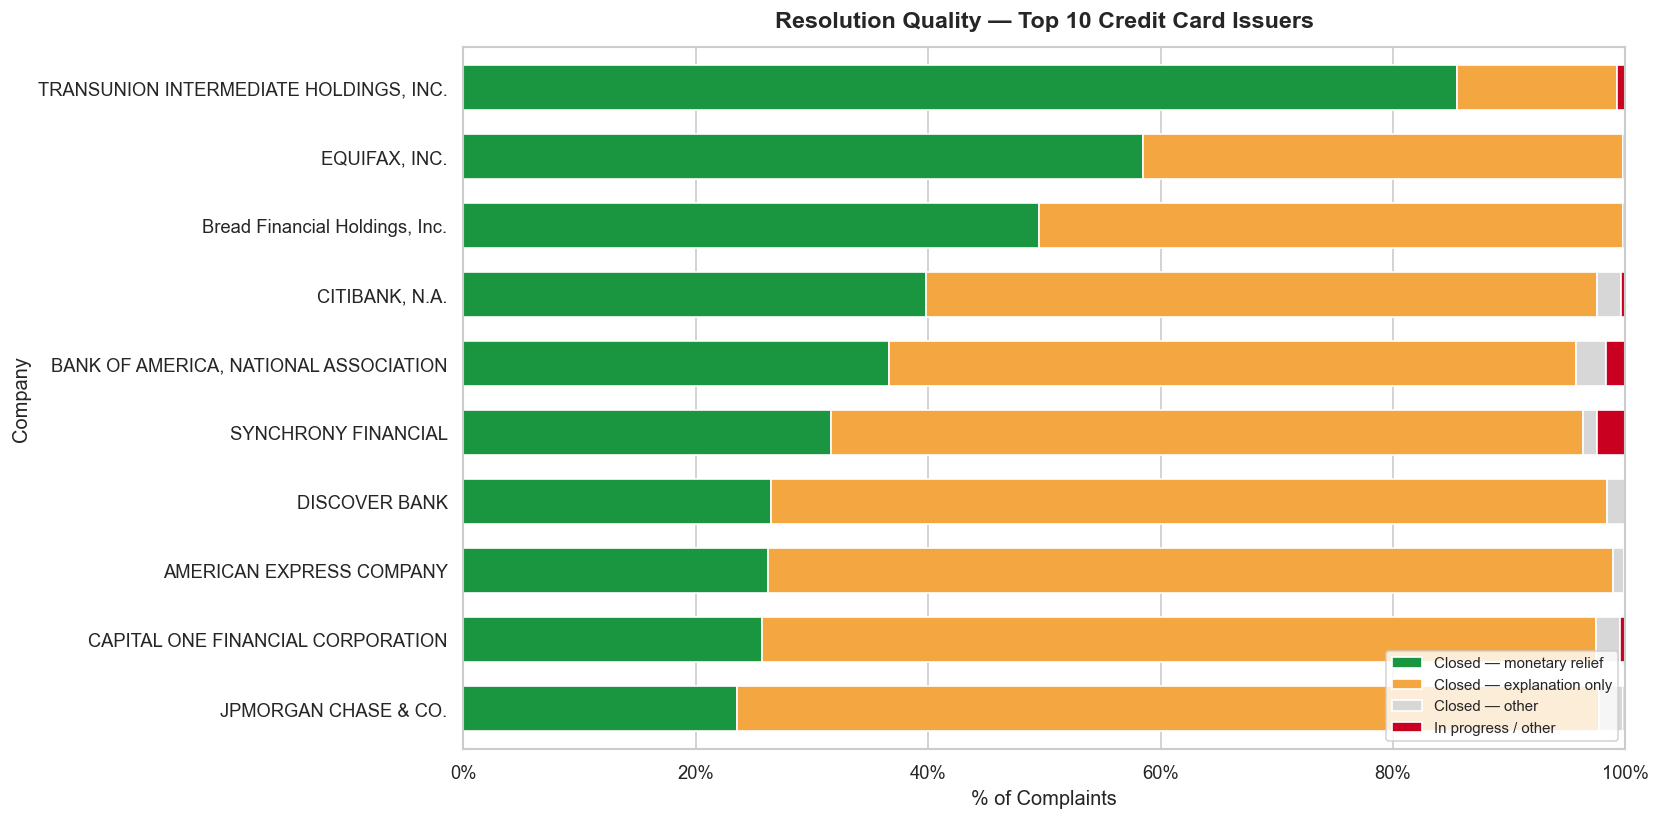

Saved → outputs/04_resolution_quality.png


In [15]:
top10 = df["Company"].value_counts().head(10).index.tolist()

def simplify_response(r):
    r = str(r).lower()
    if "monetary relief" in r:
        return "Closed — monetary relief"
    elif "non-monetary relief" in r:
        return "Closed — non-monetary relief"
    elif "explanation" in r:
        return "Closed — explanation only"
    elif "closed" in r:
        return "Closed — other"
    else:
        return "In progress / other"

df_res = df[df["Company"].isin(top10)].copy()
df_res["Response_Simple"] = df_res["Company response to consumer"].apply(simplify_response)

pivot = (
    df_res.groupby(["Company", "Response_Simple"])
    .size()
    .unstack(fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Sort by monetary relief rate (best resolvers at top)
sort_col = "Closed — monetary relief"
if sort_col in pivot_pct.columns:
    pivot_pct = pivot_pct.sort_values(sort_col, ascending=True)

PALETTE = {
    "Closed — monetary relief":     "#1a9641",
    "Closed — non-monetary relief": "#a6d96a",
    "Closed — explanation only":    "#f4a741",
    "Closed — other":               "#d7d7d7",
    "In progress / other":          "#ca0020",
}
plot_cols = [c for c in PALETTE if c in pivot_pct.columns]

ax = pivot_pct[plot_cols].plot(
    kind="barh", stacked=True,
    color=[PALETTE[c] for c in plot_cols],
    figsize=(14, 7),
    width=0.65,
)
ax.set_title("Resolution Quality — Top 10 Credit Card Issuers",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("% of Complaints")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc="lower right", fontsize=9, framealpha=0.8)
plt.tight_layout()
plt.savefig(OUT_DIR / "04_resolution_quality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/04_resolution_quality.png")


## 7. Executive Summary

The code below computes the headline numbers from the data and prints
a 3-point summary in plain English — the kind of output you'd paste into
a slide or a compliance report.


In [16]:
total      = len(df)
date_min   = df["Date received"].min().strftime("%b %Y")
date_max   = df["Date received"].max().strftime("%b %Y")
top_issue  = df["Issue"].value_counts().idxmax()
top_issue_pct = df["Issue"].value_counts().iloc[0] / total * 100

low_timely = (
    df.groupby("Company")["Timely response?"]
    .apply(lambda x: (x.str.lower() == "yes").mean() * 100)
    .loc[lambda s: s.index.isin(df["Company"].value_counts().head(20).index)]
    .nsmallest(3)
)

top_state = state_df.nlargest(1, "Per_100k").iloc[0]
low_state = state_df.nsmallest(1, "Per_100k").iloc[0]

print("=" * 68)
print("  CFPB CREDIT CARD COMPLAINT ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 68)
print(f"  Dataset: {total:,} complaints · {date_min} → {date_max}\n")

print(f"  1. COMPLAINT DRIVERS")
print(f"     '{top_issue}' is the #1 complaint category,")
print(f"     representing {top_issue_pct:.1f}% of all credit card complaints.")
print(f"     Billing disputes, fraud, and account management round out")
print(f"     the top 5 — together accounting for the majority of volume.")

print(f"\n  2. ISSUER RESPONSE QUALITY")
print(f"     The following major issuers have the lowest timely response rates")
print(f"     among the top 20 by volume — a leading CFPB compliance indicator:")
for company, rate in low_timely.items():
    flag = "  ⚠" if rate < 90 else ""
    print(f"     · {company[:40]:<40} {rate:.1f}%{flag}")
print(f"     Any rate below 90% risks supervisory escalation.")

print(f"\n  3. GEOGRAPHIC CONCENTRATION")
print(f"     {top_state['State']} has the highest complaint rate at")
print(f"     {top_state['Per_100k']:.0f} per 100k residents. {low_state['State']} has the lowest at")
print(f"     {low_state['Per_100k']:.0f} per 100k — a {top_state['Per_100k'] / low_state['Per_100k']:.1f}x spread across states.")

print(f"\n  RECOMMENDED ACTION FOR A CARD PROGRAM TEAM")
print(f"  → Flag issuers below 90% timely response for monthly compliance review.")
print(f"  → Investigate states with >2x the national average rate —")
print(f"     disproportionate volume may signal servicing gaps or portfolio mix.")
print(f"  → Track the top issue category month-over-month; a rising trend")
print(f"     warrants proactive UDAAP risk assessment before CFPB outreach.")
print("=" * 68)


  CFPB CREDIT CARD COMPLAINT ANALYSIS — EXECUTIVE SUMMARY
  Dataset: 549,582 complaints · Dec 2011 → Sep 2026

  1. COMPLAINT DRIVERS
     'Problem with a purchase shown on your statement' is the #1 complaint category,
     representing 20.4% of all credit card complaints.
     Billing disputes, fraud, and account management round out
     the top 5 — together accounting for the majority of volume.

  2. ISSUER RESPONSE QUALITY
     The following major issuers have the lowest timely response rates
     among the top 20 by volume — a leading CFPB compliance indicator:
     · CLGF Holdco 1, LLC                       94.4%
     · BANK OF AMERICA, NATIONAL ASSOCIATION    97.4%
     · WELLS FARGO & COMPANY                    97.7%
     Any rate below 90% risks supervisory escalation.

  3. GEOGRAPHIC CONCENTRATION
     DC has the highest complaint rate at
     425 per 100k residents. ND has the lowest at
     61 per 100k — a 6.9x spread across states.

  RECOMMENDED ACTION FOR A CARD PROGRA